# Mini-batch Gradient Descent

## What it is
Instead of computing the gradient on **all** data every step, we use a small **batch**:
- **Mini-batch** — a small chunk (e.g. 64) per step — the real-world default

**Vocabulary:**
- **batch size** — data per step (e.g. 64)
- **step** — one weight update (one batch)
- **epoch** — one full pass through all data = (total ÷ batch size) steps

## The problem it solves: SPEED
Real datasets have millions of points. Computing the gradient over *all* of them for
*every* step is too slow. Mini-batch takes many quick, slightly-noisy steps instead of
few slow, perfect ones — reaching a good loss with far less total computation.

We'll compare full-batch vs mini-batch by plotting **loss vs compute** (data points
processed), which is the fair comparison.

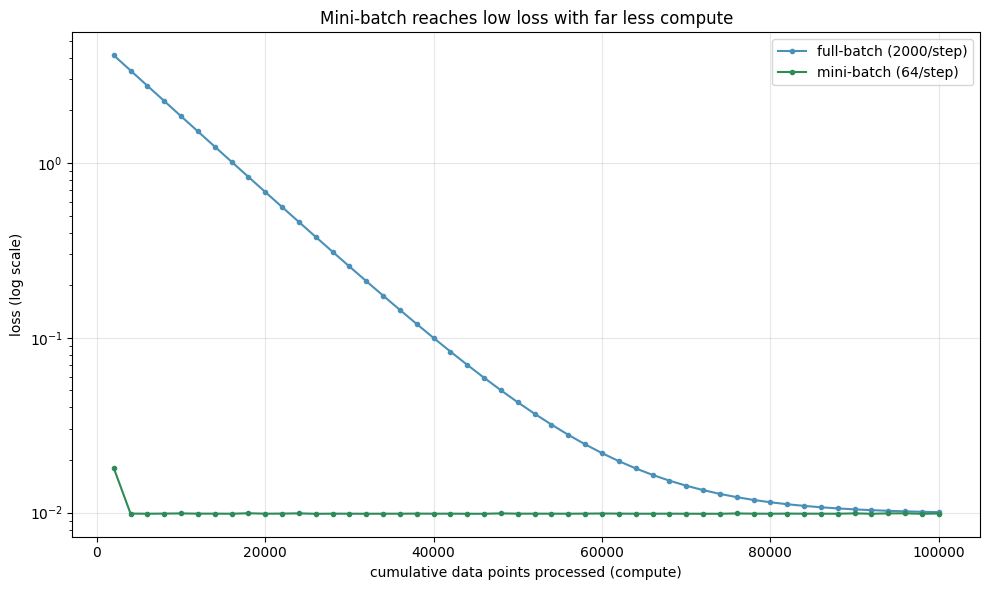

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# dataset: 2000 points, 3 features, linear target
N, D = 2000, 3
X = np.random.randn(N, D)
true_w = np.array([2.0, -1.0, 0.5])
y = X @ true_w + 0.1*np.random.randn(N)

def mse(X, y, w):    return np.mean((X @ w - y)**2)
def grad(Xb, yb, w): return (2/len(yb)) * (Xb.T @ (Xb @ w - yb))

eta = 0.05

def full_batch(epochs=50):
    w = np.zeros(D); hist = []; compute = 0
    for ep in range(epochs):
        w = w - eta*grad(X, y, w)       # ALL data -> 1 step per epoch
        compute += N
        hist.append((compute, mse(X, y, w)))
    return w, np.array(hist)

def mini_batch(epochs=50, batch_size=64):
    w = np.zeros(D); hist = []; compute = 0
    for ep in range(epochs):
        idx = np.random.permutation(N)              # shuffle each epoch
        for s in range(0, N, batch_size):
            b = idx[s:s+batch_size]
            w = w - eta*grad(X[b], y[b], w)          # only batch_size points
            compute += len(b)
        hist.append((compute, mse(X, y, w)))
    return w, np.array(hist)

w_fb, hist_fb = full_batch()
w_mb, hist_mb = mini_batch()


plt.figure(figsize=(10,6))
plt.plot(hist_fb[:,0], hist_fb[:,1], 'o-', color='#4a90b8',
         label='full-batch (2000/step)', markersize=3)
plt.plot(hist_mb[:,0], hist_mb[:,1], 'o-', color='#2e8b57',
         label='mini-batch (64/step)', markersize=3)
plt.yscale('log')
plt.xlabel('cumulative data points processed (compute)')
plt.ylabel('loss (log scale)')
plt.title('Mini-batch reaches low loss with far less compute')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

In [4]:
def compute_to_reach(hist, target=0.02):
    for c, l in hist:
        if l < target: return int(c)
    return None

print("Final loss  full-batch:", round(mse(X,y,w_fb),5))
print("Final loss  mini-batch:", round(mse(X,y,w_mb),5))
print("\nCompute to reach loss < 0.02:")
print("  full-batch:", compute_to_reach(hist_fb))
print("  mini-batch:", compute_to_reach(hist_mb))

Final loss  full-batch: 0.01007
Final loss  mini-batch: 0.00989

Compute to reach loss < 0.02:
  full-batch: 62000
  mini-batch: 2000
